---   
 <img align="left" width="75" height="75"  src="https://upload.wikimedia.org/wikipedia/en/c/c8/University_of_the_Punjab_logo.png"> 

<h1 align="center">Department of Data Science</h1>

---
<h3><div align="right">Instructor: Muhammad Arif Butt, Ph.D.</div></h3>    

<br><br>
<h1 align="center">Lec-17: Hands-on Understanding of Vectorization</h1>

# Learning agenda of this notebook  
1. What is Vectorization and Why We Need it?
2. Frequency Based Text Vectorization Techniques
    - Bag of Words Vectorization using `CountVectorizer`
    - Bag of Words Vectorization `TfidfVectorizer`
3. Prediction Based Text Vectorization Techniques (Embeddings)
    - Static Embedding Models (Word2Vec, GloVe, FastText)
    - Contextual Embedding Models (ELMo, BERT, GPT, T5)
4. Hands-On Embedding Vectors using SentenceTransformers `all-MiniLM-L6-v2` (local, Hugging Face)
   - Generating  Embedding Vectors
   - Computing Similarity Scores
   - Performing Vector Arithmetic
5. Hands-On Embedding Vectors using OpenAI Embeddings `text-embedding-3-small` (remote API calls)
   - Generating  Embedding Vectors
   - Computing Similarity Scores
   - Performing Vector Arithmetic
6. Visualize Vectors using t-SNE

# <span style='background :lightgreen' >1. What is Vectorization and Why We Need it?</span>


<h3 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">The Token IDs donot capture meanings of words, so they are passed into the <b>Embedding</b> layer, where each tokenID is mapped to a dense vector using a look-up table of <it>Vocabulary Size × Embedding Dimension</it> (512, 768, or 1024). Each embedding captures the semantic meaning of the token, i.e., words with similar meanings lie closer in embedding space.</h3>


<div style="text-align:center;">
    <img src="../images/embeddings11-old.png"
         style="max-width:1500px; width:100%; height:auto; display:inline-block;">
</div>

# <span style='background :lightgreen' >2. Frequency Based Text Vectorization Techniques</span>

<h3 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">BoW and TF-IDF are classical, pre-LLM text vectorization techniques that rely on word frequency statistics rather than learned language understanding (used with Logistic Regression, Naive Bayes and SVMs.</h3>

- Interested  Students can watch following video on `CountVectorizer` and `TfidfVectorizer`:
    - **[Bag of Words vs TFIDF by Arif](https://www.youtube.com/watch?v=CUXc-caMKw8&list=PL7B2bn3G_wfANUMx-dOv_qACGKchtDWum&index=4)**

## a. Bag of Words Vectorization using `CountVectorizer` class of `sklearn` library

<h3 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">In Bag-of-Words, a vector is a long list of numbers where each position corresponds to a word in the vocabulary, and the value tells how many times that word appears in the input text or mere its presence/absence.</h3>

<img src="../images/bagofwords.png" style="float: right; width: 1000px; margin-left: 10px; border-radius: 8px;">

- Language is a tricky concept for computers. Text is unstructured in nature and loses its meaning when represented by zeros and ones (individual characters). As a result, throughout the history of Language AI,there has been a large focus on representing language in a structured manner so that it can more easily be used by computers.
- Vectors or embeddings play a crucial role in the functioning of LLMs and generative AI. To understand their significance, it’s essential to grasp what vectors/embeddings are and how they are generated and utilized in LLMs.
- **Bag of Words (BoW)** is the most basic strategy for converting a text document into numbers, which specifies the presence/count of a word/n-grams in a vocabulary
- **Bag-of-Words (BoW)** represents text as large, sparse vectors that simply count the presence of words, without capturing context or meaning. It works as follows:
    - Let’s assume that we have two sentences for which we want to create numerical representations.
    - The first step of the bag-of-words model is tokenization, the process of splitting up the sentences into individual words or subwords (tokens).
    - The most common method for tokenization is by splitting on a whitespace to create individual words. However, this has its disadvantages as some languages, like Mandarin, do not have whitespaces around individual words.
    - After tokenization, we combine all unique words from each sentence to create a vocabulary that we can use to represent the sentences.
- The most common NLP application in which we use Bow representation is text classification (e.g., classifing a collection of documents to categories like sports, entertainment and politics).
- Although **Bag-of-words** is an elegant approach, but it has a flaw. It considers language to be nothing more than an almost literal bag of words and ignores the semantic nature, or meaning, of text.

### What does `CountVectorizer` Do?
- **Scikit-learn’s CountVectorizer** The CountVectorizer computes the frequency of occurrence of a word in a document. It converts the corpus of multiple documents (say product reviews) into a Document Term Matrix (a sparce matrix). It also allows you to:
    >- control your n-gram size, 
    >- perform custom preprocessing, 
    >- perform custom tokenization, 
    >- eliminate stop words and 
    >- limit vocabulary size.

### Hands-on Example: `CountVectorizer`

- Consider the following corpus that consists of three documents consisting of five, ten, and five words respectively and the corresponding vocabulary of the corpus:
<h3 align="left" style="font-family:'Courier New'">doc1=["Arif youTube lectures are amaizing"]</h3>
<h3 align="left" style="font-family:'Courier New'">doc2=["I like youTube lectures and Khurram also like youTube lectures"]</h3>
<h3 align="left" style="font-family:'Courier New'">doc3=["Arif youTube lectures are great"]</h3>

<br>
<h3 align="left" style="font-family:'Courier New'">vocab = {'also': 0, 'amaizing': 1, 'and': 2, 'are': 3, 'arif': 4, 'great': 5, 'khurram': 6, 'lectures': 7, 'like': 8, 'youtube': 9}</h3>

- Irrespective of the size, each document is converted into a v-dimensional **` frequency vector`**, where `v` is the size of vocabulary. 
- The three documents are represented as a **`Document-Term Matrix (DTM)`**, which is a mathematical matrix that describes the frequency of terms that occur in a collection of documents
<img align="center" color=red width="900"  src="../images/bow-dtm.png"  > 
<br>

>- Doc1 has a total of 5 words each appearing once, and it is represented as a vector of size 10 (count of vocab), having 5 non-zero values
>- Doc2 has a total of 9 words with 6 unique words (excluding single character `I`). The word `like`, `youTube`, and `lectures` are coming twice, rest all words are appearing once. Doc2 is represented as a vector of size 10 (count of vocab), having 6 non-zero values
>- Doc3 has a total of 5 words each appearing once, and it is represented as a vector of size 10 (count of vocab), having 5 non-zero values


<h4 align="left" style="font-family:'Courier New'">doc1=["Arif youTube lectures are amaizing"] = [0,1,0,1,1,0,0,1,0,1]</h4>

<h4 align="left" style="font-family:'Courier New'">doc2=["I like youTube lectures and Khurram also like youTube lectures"] = [1,0,1,0,0,0,1,2,2,2]</h4>

<h4 align="left" style="font-family:'Courier New'">doc3=["Arif youTube lectures are great"] = [0,0,0,1,1,1,0,1,0,1]</h4>

In [1]:
#####################################################################
# Generating a Bag of **Uni-grams** from a corpus of three documents
#####################################################################
from sklearn.feature_extraction.text import CountVectorizer

count_vec = CountVectorizer(
                    vocabulary = None,      # If None → vocabulary is automatically built from the corpus. You can also pass a dictionary: {"word": index, ...}
                    lowercase=True,         # Converts all text to lowercase before tokenizing (Default = True)
                    tokenizer=None,         # If None → default tokenizer is used, which removes punctuation, special chars, and single letters. You can pass your custom function if you want different behavior.
                    stop_words=None,        # Default = None → keeps all words, including the stop words. You may use stop_words='english' or pass your own list.
                    preprocessor=None,      # Allows custom preprocessing before tokenization: e.g., removing numbers, stemming, lemmatizing, etc.
                    binary=False,           # Default = False → uses raw word frequency counts (0,1,2,3,…).  If True → converts counts to 0/1 (word absent/present), which is good for sentiment analysis.
                    max_features=None,      # Limits vocabulary size to the top-N most frequent words. Default = None → no limit.
                    ngram_range=(1, 1)      # Default: (1,1) → will create a vocabulary and later a bag of uni-grams only. (2,2) = bag of bigrams. (3,3) = bag of trigrams. (1,2) = bag of unigrams and bigrams.
    
                )
# SAMPLE CORPUS
corpus = [
    "Arif youTube lectures are amaizing", 
    "I like youTube lectures and Khurram also like youTube lectures",
    "Arif youTube lectures are great"
]

# fit() step, scans the entire corpus, identifies all unique words (after tokenization, stopword removal, etc.), builds the vocabulary dictionary
# transform() step, converts each document into a vector as per the size of the vocabulary, containing word count
# returns a Document-Term Matrix (DTM)
bow = count_vec.fit_transform(corpus)

print("Vocabulary:\n", count_vec.vocabulary_, "\n")  # Vocabulary dictionary (word → index)
print("Shape of Document-Term Matrix: ", bow.shape, "\n") # Shape of the DTM (documents x unique_words)
print("Document-Term Matrix (as dense):\n") # Dense matrix view for better visualization
print(bow.todense())

Vocabulary:
 {'arif': 4, 'youtube': 9, 'lectures': 7, 'are': 3, 'amaizing': 1, 'like': 8, 'and': 2, 'khurram': 6, 'also': 0, 'great': 5} 

Shape of Document-Term Matrix:  (3, 10) 

Document-Term Matrix (as dense):

[[0 1 0 1 1 0 0 1 0 1]
 [1 0 1 0 0 0 1 2 2 2]
 [0 0 0 1 1 1 0 1 0 1]]


In [2]:
#####################################################################
# Generating a Bag of **Bi-grams** from a corpus of three documents
#####################################################################
from sklearn.feature_extraction.text import CountVectorizer

count_vec = CountVectorizer(
                    vocabulary = None,      # If None → vocabulary is automatically built from the corpus. You can also pass a dictionary: {"word": index, ...}
                    lowercase=True,         # Converts all text to lowercase before tokenizing (Default = True)
                    tokenizer=None,         # If None → default tokenizer is used, which removes punctuation, special chars, and single letters. You can pass your custom function if you want different behavior.
                    stop_words=None,        # Default = None → keeps all words, including the stop words. You may use stop_words='english' or pass your own list.
                    preprocessor=None,      # Allows custom preprocessing before tokenization: e.g., removing numbers, stemming, lemmatizing, etc.
                    binary=False,           # Default = False → uses raw word frequency counts (0,1,2,3,…).  If True → converts counts to 0/1 (word absent/present), which is good for sentiment analysis.
                    max_features=None,      # If you want to put a limit on vocabulary size, then you pass an integer value to this argument. For example a value of 100 will keep the top 100 most frequent words in the vocabulary and drop the rest.
                    ngram_range=(2, 2)      # Default: (1,1) → will create a vocabulary and later a bag of uni-grams only. (2,2) = bag of bigrams. (3,3) = bag of trigrams. (1,2) = bag of unigrams and bigrams.
    
                )
# SAMPLE CORPUS
corpus = [
    "Arif youTube lectures are amaizing", 
    "I like youTube lectures and Khurram also like youTube lectures",
    "Arif youTube lectures are great"
]


# fit() step, scans the entire corpus, identifies all unique words (after tokenization, stopword removal, etc.), builds the vocabulary dictionary
# transform() step, converts each document into a vector as per the size of the vocabulary, containing word count
# returns a Document-Term Matrix (DTM)
bow = count_vec.fit_transform(corpus)


print("Vocabulary:\n", count_vec.vocabulary_, "\n")  # Vocabulary dictionary (word → index)
print("Shape of Document-Term Matrix: ", bow.shape, "\n") # Shape of the DTM (documents x unique_words)
print("Document-Term Matrix (as dense):\n") # Dense matrix view for better visualization
print(bow.todense())

Vocabulary:
 {'arif youtube': 4, 'youtube lectures': 9, 'lectures are': 7, 'are amaizing': 2, 'like youtube': 8, 'lectures and': 6, 'and khurram': 1, 'khurram also': 5, 'also like': 0, 'are great': 3} 

Shape of Document-Term Matrix:  (3, 10) 

Document-Term Matrix (as dense):

[[0 0 1 0 1 0 0 1 0 1]
 [1 1 0 0 0 1 1 0 2 2]
 [0 0 0 1 1 0 0 1 0 1]]


> **Limitation of BoW Technique:** BoW approach treats every word equally, irrespective of its actual importance.

## b. Bag of Words Vectorization using `TfidfVectorizer` class of `sklearn` library

<h3 align="center"><div class="alert alert-success" color=magenta style="margin: 20px"><b>TF-IDF Score</b> is a numerical value that indicates how important a word is in a document by giving higher weight to words that appear frequently in that document but rarely in other documents.</h3>


### a. Conceptual Understanding
- In Bag of Words representation of a document, the values of the vector are the number of times a particular word appears in a document, but it do not capture the importance of a word in a document. 
- In simple words BoW approach treats every word equally, irrespective of its actual importance.
- So BoW gives more importance to some un-important words that appears more frequently in a document. For example, words like `since`, `as`, `can`, `any`, `and`, `the`, `of`, `'it`, `they` can have high frequency but are not important.
- This will take the attention of the machine learning model away from less frequent but more important words.
- **TF-IDF** stands for Term Frequency(TF) times Inverse Document Frequency(IDF) and it is used to address this issue.
    - The `Term Frequency` tells us how important a term is in a particular document, by assigning more weight to a term that is appearing more frequently in a dataset.
    - The `Document Frequency` tells us how important a term is in the entire corpus of documents. The intution behind taking its inverse is that more common a word is across all documents, the lesser its importance is for the current document.
#### (i) Term Frequency (TF)
- Term Frequency tells us the count of a term in a specific document and thus tells us how important a term is in a particular document.
- In literature there are three different formulae that I found for computing **TF** shown below:

\begin{equation}
      \text{TF (t, d)} \hspace{0.5cm}=\hspace{0.5cm} \text{Number of times term (t) occurs in document (d)}
\end{equation}


\begin{equation}
      \text{TF (t, d)} \hspace{0.5cm}=\hspace{0.5cm} \frac{ \text{Number of times term (t) occurs in document (d)}}{\text{Total number of terms in document (d)}}
\end{equation}

\begin{equation}
      \text{TF (t, d)} \hspace{0.5cm}=\hspace{0.5cm} \frac{ \text{Number of times term (t) occurs in document (d)}}{\text{Frequency of most common term in document (d)}}
\end{equation}

- Consider a corpus of three documents as shown below:

<h3 align="left" style="font-family:'Courier New'">doc1 = ["Arif youTube lectures are amaizing"]</h3>

<h3 align="left" style="font-family:'Courier New'">doc2=["I like youTube lectures and Khurram also like youTube lectures"]</h3>

<h3 align="left" style="font-family:'Courier New'">doc3=["Arif youTube lectures are great"] </h3>


>- **The `TfidfVectorizer()` method of sklearn use the first formula**


<img align="center" color=red width="1000"  src="../images/tf.png"  > 

>- Doc1 has a total of 5 words each appearing once, and it is represented as a vector of size 10 (count of vocab), having 5 non-zero values
>- Doc2 has a total of 10 words with 6 unique words (excluding single character `I`). The word `like`, `youTube`, and `lectures` are coming twice, rest all words are appearing once. Doc2 is represented as a vector of size 10 (count of vocab), having 6 non-zero values
>- Doc3 has a total of 5 words each appearing once, and it is represented as a vector of size 10 (count of vocab), having 5 non-zero values

#### (ii) Inverse Document Frequency (IDF)
- Document Frequency tells us how important a term is in the entire corpus of documents.
- But since we want to **penalize frequently occurring words across all the documents**, so we take the Inverse of Document Frequency.
- This way the IDF of rare words in the corpus will be large, while the IDF of very common words in the corpus will be close to zero.
- In literature there are different formulae that I found for computing **IDF**. The most common is:
\begin{equation}
      \text{IDF (t, D)} \hspace{0.5cm}=\hspace{0.5cm} log_e\frac{n}{df(d,t)}
\end{equation}
- Where,
    - `n` = Total number of documents in the corpus
    - `df(d,t)` = Number of documents in which term `t` appears
    >- In a corpus having large number of documents (large value of n), if a word is appearing in only one document, then the IDF value of that term will be very large. Therefore, we take the natural logarithm to dampen its effect.
- The `TfidfVectorizer()` method of sklearn use the following formula, when the argument `smooth_idf=True`.
\begin{equation}
      \text{IDF (t, D)} \hspace{0.5cm}=\hspace{0.5cm} 1 + log_e\frac{1 + n}{1+ df(d,t)}
\end{equation}
- If `smooth_idf=True` (the default), the constant “1” is added to the numerator and denominator, which prevents zero divisions
- The reason of adding “1” to the IDF in the equation above is that terms with zero IDF, i.e., terms that occur in all documents in a training set, will not be entirely ignored.
\begin{equation}
      \text{IDF (arif, D)} \hspace{0.5cm}=\hspace{0.5cm} 1 + log_e\frac{1 + 3}{1+ 2}\hspace{0.5cm}=\hspace{0.5cm} 1 + log_e(1.333333)\hspace{0.5cm}=\hspace{0.5cm} 1 + 0.28768 \hspace{0.5cm}=\hspace{0.5cm} 1.28768
\end{equation}
\begin{equation}
      \text{IDF (youtube, D)} \hspace{0.5cm}=\hspace{0.5cm} 1 + log_e\frac{1 + 3}{1+ 3}\hspace{0.5cm}=\hspace{0.5cm} 1 + log_e(1)\hspace{0.5cm}=\hspace{0.5cm} 1 + 0 \hspace{0.5cm}=\hspace{0.5cm} 1
\end{equation}

 <img align="center" color=red width="1200"  src="../images/idf.png"  >  
 
 >- The TF vary for each term in each document, but IDF values remains same for all the terms in all the documents inside the corpus
 >- Note that a term that is appearing in all the documents like youtube, is not given a zero IDF, and this is because the "1" added in the above formula. This way the term is not entirely ignored in the over all calculation of TFIDF

### (iii) Term Frequency-Inverse Document Frequency (TFIDF) 
- TFIDF score can be calculated using following formula:

\begin{equation}
TFIDF \hspace{0.5cm}=\hspace{0.5cm} TF * IDF
\end{equation}

 <img align="center" color=red width="1200"  src="../images/tfidf.png"  >    

### (iv) Normalize TFIDF Values
- To avoid large documents in the corpus dominating smaller ones, we have to normalize each row in the sparse matrix to have the Euclidean norm. The Euclidean Norm of the three documents are 2.86059, 5.29785 and 2.86059 respectively

\begin{equation}
\text{Normalized TFIDF} \hspace{0.5cm}=\hspace{0.5cm} \frac{TFIDF}{\sqrt{\Sigma_{i=1}^{n} TFIDF^2}}
\end{equation}


<img align="center" color=red width="1200"  src="../images/normalized-tfidf.png"  >    

>- **The higher is the TFIDF score, the more relevant the term is in that document**
>- In doc1, the term “amaizing” is the most relevant term as it has the highest tf-idf value (0.59188659)
>- In doc2, the term “like” is the most relevant term as it has the highest tf-idf value (0.63918256)
>- In doc3, the term “great” is the most relevant term as it has the highest tf-idf value (0.59188659)

### Hands-on Example: `TfidfVectorizer`

In [3]:
# Generating a BoW from a corpus of three documents using TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Creating a TF-IDF Vectorizer with default values
tfidf_vec = TfidfVectorizer(
                             input='content',                 # Accepts file paths or raw content. 'content' means raw text.
                             strip_accents=None,              # Removes accents if set to 'ascii' or 'unicode'.
                             lowercase=True,                  # Converts all text to lowercase before processing.
                             preprocessor=None,               # Custom preprocessing function (cleaning, stemming, etc.).
                             tokenizer=None,                  # Custom tokenization function.
                             stop_words=None,                 # Removes stop words (‘english’) or custom list.
                             token_pattern=r"(?u)\b\w\w+\b",  # Default: tokens of 2+ characters.
                             ngram_range=(1, 1),              # (1,1)=unigrams, (1,2)=uni+bi-grams, etc.
                             max_df=1.0,                      # Ignore words in >100% of docs (useless but default).
                             min_df=1,                        # Keep words appearing in at least 1 document.
                             max_features=None,               # Limit vocabulary size (None = keep all).
                             vocabulary=None,                 # A custom vocabulary dictionary if supplied.
                             norm='l2',                       # Normalizes each document vector ('l1', 'l2', or None)
                             use_idf=True,                    # Use Inverse Document Frequency (IDF) weighting.
                             smooth_idf=True,                 # Adds 1 to document frequencies to avoid division by zero.
                             sublinear_tf=False,              # If True: apply log-scaling to term frequency (1 + log(tf)).
                         )

# SAMPLE CORPUS
corpus = [
    "Arif youTube lectures are amaizing", 
    "I like youTube lectures and Khurram also like youTube lectures",
    "Arif youTube lectures are great"
]

# fit() step, scans the entire corpus, identifies all unique words (after tokenization, stopword removal, etc.), builds the vocabulary dictionary
# transform() step, converts each document into a vector as per the size of the vocabulary, containing TF-IDF weights for each word in each document
# returns a Document-Term Matrix (DTM)
bow = tfidf_vec.fit_transform(corpus) 


print("Vocabulary:\n", tfidf_vec.vocabulary_, "\n")       # Vocabulary dictionary (word → index)
print("Shape of Document-Term Matrix: ", bow.shape, "\n") # Shape of the DTM (num_documents x num_unique_words)
print("Document-Term Matrix (as dense):\n")               # Displaying the TF-IDF matrix in dense form for clarity
print(bow.todense())                   

Vocabulary:
 {'arif': 4, 'youtube': 9, 'lectures': 7, 'are': 3, 'amaizing': 1, 'like': 8, 'and': 2, 'khurram': 6, 'also': 0, 'great': 5} 

Shape of Document-Term Matrix:  (3, 10) 

Document-Term Matrix (as dense):

[[0.         0.59188659 0.         0.45014501 0.45014501 0.
  0.         0.34957775 0.         0.34957775]
 [0.31959128 0.         0.31959128 0.         0.         0.
  0.31959128 0.37751152 0.63918256 0.37751152]
 [0.         0.         0.         0.45014501 0.45014501 0.59188659
  0.         0.34957775 0.         0.34957775]]


### Advantage of using TFIDF
- TF‑IDF quantifies the importance of words in a document by combining term frequency (TF) with inverse document frequency (IDF), so words that are frequent in a document but rare across the corpus get higher scores, making them more informative.
- It down‑weights common words like “the” or “and” without needing a manually defined stop‑word list.
- TF‑IDF is simple and easy to implement and widely supported by libraries like Scikit‑learn, making it a strong baseline for many NLP pipelines.
- The resulting TF‑IDF representation is interpretable and model‑agnostic — the vector values clearly reflect term importance.
- It is effective in traditional information retrieval and text classification tasks, and performant on small to medium datasets where complex embedding models are unnecessary.
### Limitations of using TFIDF
- **Ignores word order** e.g, cannot distinguish between phrases like “cat chased dog” vs “dog chased cat”.
- **Does not capture semantic meaning:** synonyms like “car” and “vehicle” receive unrelated scores despite similar meaning.
- **Ignores context** e.g., cannot distinguish between phrases like "money bank" vs "river bank".
- **Vector dimensionality equals the vocabulary size** which can be very large and sparse, leading to high memory usage and inefficient computation.
- **Rare words can receive disproportionately high weights**, which may emphasize noise rather than meaningful content.
- **OOV Problem** TF‑IDF is limited to the vocabulary of the training corpus and cannot handle unseen (out‑of‑vocabulary) words at inference time.

# <span style='background :lightgreen' >3. Prediction Based Text Vectorization Techniques (Embeddings)</span>
<h3 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">Word Embedding is a technique, where each word/token is represented as a dense n-dimensional numerical vector that encode the semantic and contextual meaning of the token. Words having similar meanings are positioned closer together, enabiling models to perform tasks like similarity measurement, semantic search, clustering and information retrieval. </h3>


- The core idea is to represent words as **dense, low-dimensional vectors** that capture **semantic meaning** and **distributional similarity** to overcome the limitations of sparse, high-dimensional representations used in statistical and early ML methods.
- **Embeddings** are high-dimensional vectors that capture the semantic meaning of words, sentences or even entire documents. The process of converting text into embeddings allows LLMs to perform various natural language processing tasks, such as text generation, sentiment analysis and more.
- Operations on vectors, such as a dot product, help us discover whether two vectors are identical or different. At a high level, this forms the basis for performing similarity search on vectors stored in memory or in specialized vector databases.
- Through embeddings, modern NLP models achieve a deep understanding of language, enabling tasks like sentiment analysis, text summarization, and question answering with nuanced comprehension and generation capabilities. They serve as the foundation for LLMs, but are also used independently to convert text into vectors while retaining semantic context. When text is passed through an embedding model, a vector is produced that contains the embeddings. 

<div style="text-align: center;">
    <img src="../images/vectorizationA.png" width="1500">
</div>


### Vector Arithmetic:
<font color="purple">

- **king – man + woman = ?**
- **brother – man + woman = ?**
- **actor – man + woman = ?**
- **walking – walk + run = ?**
- **talked – talk + play = ?**
- **big – bigger + small = ?**
- **Bangladesh – Dhaka + Pakistan = ?**

</font>

<details>
<summary><b>💡 Click to reveal answer</b></summary>

<font color="purple">

- **king – man + woman = queen**
- **brother – man + woman = sister**
- **actor – man + woman = actress**
- **walking – walk + run = running**
- **talked – talk + play = played**
- **big – bigger + small = smaller**
- **Bangladesh – Dhaka + Pakistan = Islamabad**

</font>

</details>

# Embedding Models
<div style="text-align: center;">
    <img src="../images/embedding-models.png" width="1500">
</div>

## a. Static Embedding Models
<h3 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">Static embeddings generate word vectors that assign the same fixed representation to a word every time it appears, regardless of context.</h3>

- **Word2Vec (Google, 2013, https://arxiv.org/pdf/1301.3781.pdf):** Creates static word embeddings by predicting neighboring words in a fixed context window, producing the same vector for each word regardless of context. It learns embeddings using neural networks with two main architectures:
    - *Continuous Bag of Words (CBOW)* Take into consideration the words that are around a given target words and the goal is the predict the target words. (Predicts a word from its surrounding context)
    - *Skip-Gram* is the opposite, in which you predicts surrounding context words from a given word.
- **GloVe (Stanford, 2014, https://nlp.stanford.edu/pubs/glove.pdf):** Combines global matrix factorization with local context window methods to create word vectors that capture both global statistical information and local context patterns. It leverages word co-occurrence statistics from the entire corpus to learn embeddings that perform well on word analogy tasks. GloVe stands for "Global Vectors for Word Representation" and often achieves competitive performance with Word2Vec while being more computationally efficient to train.
- **FastText (Facebook, 2016, https://arxiv.org/pdf/1607.01759.pdf):** Extends Word2Vec by incorporating subword information (character n-grams), making it better at handling out-of-vocabulary words and morphologically rich languages. It represents each word as a bag of character n-grams, allowing it to generate embeddings for words not seen during training by combining subword representations. This approach is particularly effective for languages with rich morphology like Turkish, Finnish, or German where word forms can vary significantly.

### Limitations of static embeddings (NO Context Awareness):
- The same word always gets the same vector
- In sentences, **"I deposited a cheque in bank"** and **"I slipped at the river bank"**, the word bank will get the same embeddings, making it impossible to distinguish between the two meanings.
- In sentences, **"This apple is red and juicy"** and **"Apple launched a new phone"** the word apple will get the same embeddings. In the first sentence the word apple refer to a fruit, while in the second sentence the word apple refers to a company.

>- If the training data on which the embedding model is trained has 1000 occurrances of word apple as fruit and 20 occurrances of word apple as company. The resulting static embedding will be inclined  towards treating word "apple" as fruit.

## b. Contextual Embedding Models and Language Models Paradigms
<h3 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">Contextual embeddings generate word vectors that dynamically change based on the surrounding context, capturing different meanings for the same word in different sentences.</h3>
    
- Modern Natural Language Processing (NLP) systems rely on contextual embeddings, where the meaning of a word is not fixed but instead adapts based on its surrounding context.
- The field rapidly evolved with the introduction of transformer architectures, which use self-attention to capture long-range dependencies and process entire sequences in parallel.
- Based on what they are optimized to do, modern language models can be broadly organized into three overlapping paradigms:



| Architecture Type | Description | Notable Examples |
|---|---|---|
| **Encoder-only** (Representational models) | Bidirectional context representation; focus on learning rich contextualized representations (embeddings) of text.<br>These embeddings capture meaning, syntax, and relationships between words without primarily aiming to generate new text. | [BERT](https://arxiv.org/pdf/1810.04805), [RoBERTa](https://arxiv.org/pdf/1907.11692), [ALBERT](https://arxiv.org/pdf/1909.11942) |
| **Decoder-only** (Generative models) | Autoregressive language modeling that predicts the next token; dominant architecture for modern LLMs. | [GPT](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf), [GPT-2](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf), [GPT-3](https://arxiv.org/pdf/2005.14165), [LLaMA](https://arxiv.org/pdf/2302.13971) |
| **Encoder–Decoder** | Uses an encoder to understand input and a decoder to generate output; common in translation and summarization. | [T5](https://arxiv.org/pdf/1910.10683), [BART](https://arxiv.org/pdf/1910.13461), [mT5](https://arxiv.org/pdf/2010.11934) |

# How Representational Models Work?

##  Levels of Text Embedding Granularity
- This table compares different levels of text embedding granularity — from individual words to entire documents — showing how each approach represents text as vectors. It highlights the trade-offs between precision, context, and efficiency: word-level embeddings capture fine meaning but lose context, while document-level ones are compact but less specific. Sentence- and page-level embeddings strike the best balance, making them ideal for real-world applications like semantic search, question answering, and retrieval-augmented generation (RAG).

<table style="width:80%; font-size:14px; text-align:left;">
  <thead>
    <tr>
      <th><b>Level</b></th>
      <th><b>How It Works</b></th>
      <th><b>Pros</b></th>
      <th><b>Cons</b></th>
      <th><b>Use Case</b></th>
      <th><b>Tools</b></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><b>Word-level</b></td>
      <td>Each word gets a vector</td>
      <td>Very precise meaning</td>
      <td>Loses context easily</td>
      <td>Short word comparisons, synonyms</td>
      <td>Word2Vec, GloVe</td>
    </tr>
    <tr>
      <td><b>Sentence-level</b></td>
      <td>Whole sentence is vectorized</td>
      <td>Preserves meaning, good for QA</td>
      <td>Too many vectors in large docs</td>
      <td>Summarization, RAG, semantic search</td>
      <td>BERT, MiniLM</td>
    </tr>
    <tr>
      <td><b>Page-level</b></td>
      <td>Each page gets one vector</td>
      <td>Balanced size & context</td>
      <td>Topic might split across pages</td>
      <td>Book/document search</td>
      <td>SentenceTransformers</td>
    </tr>
    <tr>
      <td><b>Document-level</b></td>
      <td>One vector for the whole document</td>
      <td>Compact & fast retrieval</td>
      <td>Merges unrelated content</td>
      <td>Quick filtering, simple matching</td>
      <td>AvgVec, BERT Pooling</td>
    </tr>
  </tbody>
</table>

<p><b>🔍 Tip:</b> For most real-world use cases, sentence or page-level vectorization gives the best balance of accuracy and context.</p>

<div style="text-align: center;">
    <img src="../images/vectorizationB.png" width="1500">
</div>

#  Available Embedding Models
- Models mentioned in the following table are embedding models only (not LLMs). They are used to generate embeddings, not to perform open-ended text generation like GPT-4 or LLaMA.


| Provider | Model | Type | Best For | Dimensions | Architecture |
|----------|-------|------|----------|------------|--------------|
| **OpenAI** | text-embedding-3-small | Cloud | High quality, cost-effective | 1536 | Decoder-only |
| **OpenAI** | text-embedding-3-large | Cloud | Highest quality | 3072 | Decoder-only |
| **OpenAI** | text-embedding-ada-002 | Cloud | Legacy, stable | 1536 | Decoder-only |
| **Google** | models/embedding-001 | Cloud | Multilingual support | 768 | Encoder-only |
| **Google** | textembedding-gecko | Cloud | Text understanding | 768 | Encoder-only |
| **Cohere** | embed-english-v3.0 | Cloud | English text | 1024 | Encoder-only |
| **Cohere** | embed-multilingual-v3.0 | Cloud | Multilingual | 1024 | Encoder-only |
| **Azure OpenAI** | text-embedding-ada-002 | Cloud | Enterprise OpenAI | 1536 | Decoder-only |
| **HuggingFace** | all-MiniLM-L6-v2 | Local | Fast, lightweight | 384 | Encoder-only |
| **HuggingFace** | all-mpnet-base-v2 | Local | High quality | 768 | Encoder-only |
| **HuggingFace** | multi-qa-MiniLM-L6-cos-v1 | Local | Question-answering | 384 | Encoder-only |
| **HuggingFace** | paraphrase-multilingual-MiniLM-L12-v2 | Local | Multilingual | 384 | Encoder-only |
| **Ollama** | nomic-embed-text | Local | Privacy-focused | 768 | Encoder-only |
| **Ollama** | mxbai-embed-large | Local | Large context | 1024 | Encoder-only |
| **Sentence Transformers** | Custom models | Local | Domain-specific | Varies | Encoder-only |
| **Bedrock** | amazon.titan-embed-text-v1 | Cloud | AWS ecosystem | 1536 | Encoder-only |
| **Vertex AI** | textembedding-gecko | Cloud | Google Cloud | 768 | Encoder-only |
| **Jina** | jina-embeddings-v2-base-en | Cloud/Local | Code & text | 768 | Encoder-only |

>-  **Sentence Transformers:** - While token embeddings are key to how LLMs operate, a number of LLM applications require operating on entire sentences, paragraphs, or even text documents. This has led to special language models that produce text embeddings — a single vector that represents a piece of text longer than just one token. There are multiple ways of producing a text embedding vector. One of the most common ways is to average the values of all the token embeddings produced by the model. Yet high-quality text embedding models tend to be trained specifically for text embedding tasks.
>- **OpenAI Embedding Models:** Represent the latest generation of pre-trained embeddings (like text-embedding-3-small, text-embedding-3-large) that leverage massive transformer models trained on diverse internet text. These models excel at capturing semantic similarity across different languages and domains, making them highly effective for retrieval, clustering, and semantic search applications.


# <span style='background :lightgreen' >4. Generating Embedding Vectors using SentenceTransformers (local, Hugging Face)</span>
- **SentenceTransformers** is a Python library that provides access to pre-trained embedding models specifically designed to generate semantic embeddings for sentences, paragraphs, or individual words. It encodes text into dense vector representations that can be used for similarity search, clustering, or other NLP tasks.
- You can download and run open-source embedding models from Hugging Face directly on your local machine (CPU/GPU). These models are free to use, with no API costs or rate limits. If desired, you can also fine-tune them for domain-specific applications. However, your hardware must be capable of handling the model and performing inference efficiently.
- Some of the embedding models are:
    - `sentence-transformers/all-MiniLM-L6-v2`: Produces 384-dimensional embeddings. The core model file is relatively small (≈ 22 MB for weights), though total download may be somewhat larger to include tokenizer files and configs. It is optimized for efficiency and speed.
    - `sentence-transformers/all-mpnet-base-v2`: Produces 768-dimensional embeddings. The weight file (safetensors) is ~ 438 MB. This variant is higher-capacity and generally gives stronger embedding performance at the cost of increased resource usage.
    - `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`: Produces 384-dimensional embeddings. This model is multilingual (supports 50+ languages) and has on the order of 118 million parameters. It provides cross-lingual embedding alignment for many languages.
- When you load any of these models (e.g. via `SentenceTransformer(model_name)` or `AutoModel.from_pretrained(model_name))`, the Hugging Face Hub will download the needed files (model weights, tokenizer configuration, tokenization files) and cache them locally (e.g. under your Hugging Face cache directory). The tokenizer files can include tokenizer.json, vocab.txt, tokenizer.model, config.json, and special token maps, depending on implementation.
  
>- SentenceTransformers = lightweight, local, free, smaller embeddings → good for small projects, offline use.

In [4]:
#!pip install sentence-transformers
#!pip install hf_xet

### Example 1: Converting text to Vectors

In [5]:
# This code produces context-aware sentence embeddings, because it uses a Transformer model where self-attention dynamically adjusts word meanings based on surrounding words.
from sentence_transformers import SentenceTransformer   

# Text to vectorize
text1 = "The cat sat on the mat"
text2 = "A cat sits on a rug" 

# Load the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2') 

#Converts the text into dense vector embeddings.
vector1 = model.encode(text1)   
vector2 = model.encode(text2)

# Print Results
print(f"Text 1: {text1}")
print(f"Vector Text 1: {len(vector1)}, {vector1[:5]}")
print(f"Text 2: {text2}")
print(f"Vector Text 2: {len(vector2)}, {vector2[:5]}")

Text 1: The cat sat on the mat
Vector Text 1: 384, [ 0.13040183 -0.01187013 -0.02811704  0.05123864 -0.05597447]
Text 2: A cat sits on a rug
Vector Text 2: 384, [ 0.11013275 -0.00940966  0.02270846  0.05102444 -0.06315673]


## How to Compute Similarity between Embeddings (Static and Contextual)

<div style="text-align: center;">
    <img src="../images/text-rep2.png" width="1500">
</div>

<table style="width:100%; text-align:center; table-layout:fixed;">
  <tr>
    <td style="padding:5px; vertical-align:top;">
      <img src="../images/similarity-1.png" width="100%"><br>
      <strong>Cosine Similarity</strong>
    </td>
    <td style="padding:5px; vertical-align:top;">
      <img src="../images/similarity-2.png" width="100%"><br>
      <strong>Euclidean Distance</strong>
    </td>
    <td style="padding:5px; vertical-align:top;">
      <img src="../images/similarity-3.png" width="100%"><br>
      <strong>Dot Product</strong>
    </td>
  </tr>
</table>

<table style="width:100%; font-size:14px; border-collapse:collapse; line-height:1.6;">
  <thead>
    <tr style="background-color:#e8f4fa;">
      <th style="padding:10px; border:1px solid #ccc;">🔍 Method</th>
      <th style="padding:10px; border:1px solid #ccc; width:12%; text-align:center;">⚙️ Type</th>
      <th style="padding:10px; border:1px solid #ccc; width:45%;">🧠 How It Works</th>
      <th style="padding:10px; border:1px solid #ccc;">🔧 Used In</th>
    </tr>
  </thead>
  <tbody>
    <!-- Exact Techniques -->
    <tr style="background-color:#f0fbf5;">
      <td><strong>Cosine</strong></td>
      <td style="text-align:center; vertical-align:middle;">Exact</td>
      <td>Measures angle between vectors; good for semantic similarity</td>
      <td>ChromaDB</td>
    </tr>
    <tr style="background-color:#f0fbf5;">
      <td><strong>Euclidean</strong></td>
      <td style="text-align:center; vertical-align:middle;">Exact</td>
      <td>Calculates straight-line (L2) distance between vectors</td>
      <td>FAISS, Scikit-Learn</td>
    </tr>
    <tr style="background-color:#f0fbf5;">
      <td><strong>Dot Product</strong></td>
      <td style="text-align:center; vertical-align:middle;">Exact</td>
      <td>Multiplies vector pairs; common in deep learning models</td>
      <td>Transformers, PyTorch</td>
    </tr>
    <!-- ANN Techniques -->
    <tr style="background-color:#fef9e7;">
      <td><strong>HNSW (Hierarchical Navigable Small World)</strong></td>
      <td style="text-align:center; vertical-align:middle;">ANN</td>
      <td>Uses hierarchical graph structure for fast approximate search</td>
      <td>Pinecone, Weaviate, Qdrant</td>
    </tr>
    <tr style="background-color:#fef9e7;">
      <td><strong>IVF (Inverted File)</strong></td>
      <td style="text-align:center; vertical-align:middle;">ANN</td>
      <td>Divides vectors into clusters and searches only relevant ones</td>
      <td>FAISS</td>
    </tr>
    <tr style="background-color:#fef9e7;">
      <td><strong>PQ (Product Quantization)</strong></td>
      <td style="text-align:center; vertical-align:middle;">ANN</td>
      <td>Reduces memory usage by compressing vectors via quantization</td>
      <td>FAISS</td>
    </tr>
    <!-- Hybrid Techniques -->
    <tr style="background-color:#fceeee;">
      <td><strong>Filtered Vector Search</strong></td>
      <td style="text-align:center; vertical-align:middle;">Hybrid</td>
      <td>Combines vector search with metadata filtering for precision</td>
      <td>Weaviate, Elasticsearch</td>
    </tr>
    <tr style="background-color:#fceeee;">
      <td><strong>Multi-Vector Search</strong></td>
      <td style="text-align:center; vertical-align:middle;">Hybrid</td>
      <td>Uses multiple chunks or sections per document during retrieval</td>
      <td>ChromaDB, RAG systems</td>
    </tr>

  </tbody>
</table>


### a. **Cosine Similarity**
$
\text{cosine}(v_1, v_2) = \frac{v_1 \cdot v_2}{\|v_1\| \, \|v_2\|}
$

- **How it works:**
    - Measures the **angle** between two vectors.
    - Ignores vector magnitudes (lengths), focusing only on **direction**.
    - Ranges between **-1 (opposite)** and **+1 (identical direction)**.
- **Interpretation:**
    - If two embeddings point in nearly the same direction in vector space, cosine similarity will be high, even if their magnitudes differ.
    - This makes it especially good for text embeddings, where semantic meaning matters more than magnitude.

### b. **Dot Product**
$
\text{dot}(v_1, v_2) = \sum_{i=1}^{d} v_{1i} \, v_{2i}
$
- **How it works:**
    - Projects one vector onto another and multiplies by the length.
    - Sensitive to **both direction and magnitude**.
- **Interpretation:**
    - If vectors are **normalized** (length ≈ 1), the dot product becomes **numerically equal to cosine similarity**.
    - For embeddings from `SentenceTransformer`, vectors are often L2-normalized, so **dot ≈ cosine**.

### c. **Euclidean Distance**
$
\text{euclidean}(v_1, v_2) = \| v_1 - v_2 \|_2 = \sqrt{\sum_{i=1}^{d} (v_{1i} - v_{2i})^2}
$
- **How it works:**
    - Measures the **straight-line distance** between two vectors in high-dimensional space.
    - Smaller distance = higher similarity.
- **Interpretation:**
    - If embeddings are normalized, cosine similarity and euclidean distance are **monotonically related**:
$
\|v_1 - v_2\|^2 = \|v_1\|^2 + \|v_2\|^2 - 2 \, (v_1 \cdot v_2)
$
    - With normalized embeddings ($\|v\| = 1$), this simplifies to:
$
\|v_1 - v_2\|^2 = 2 - 2 \, \cos(\theta)
$
    - So minimizing Euclidean distance is **equivalent** to maximizing cosine similarity.

### Example 2: Converting text to Vectors and Calculate their Cosine Similarity using `.similarity()` method of the model

In [6]:
from sentence_transformers import SentenceTransformer   

# Text to vectorize
text1 = "The cat sat on the mat"
text2 = "A cat sits on a rug" 

# Load the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2') 

#Converts the text into dense vector embeddings.
vector1 = model.encode(text1)   
vector2 = model.encode(text2)

# Calculate similarity score using the .similarity() method of model
cos_sim = model.similarity(vector1, vector2)

# Print Results
print(f"Text 1: {text1}")
print(f"Vector Text 1: {len(vector1)}, {vector1[:5]}")
print(f"Text 2: {text2}")
print(f"Vector Text 2: {len(vector2)}, {vector2[:5]}")
print(f"Cosine similarity Score: {cos_sim.item():.4f}")

Text 1: The cat sat on the mat
Vector Text 1: 384, [ 0.13040183 -0.01187013 -0.02811704  0.05123864 -0.05597447]
Text 2: A cat sits on a rug
Vector Text 2: 384, [ 0.11013275 -0.00940966  0.02270846  0.05102444 -0.06315673]
Cosine similarity Score: 0.7373


### Example 3: Converting text to Vectors and Calculate their Cosine Similarity using `.similarity()` method of the model

In [7]:
from sentence_transformers import SentenceTransformer   

# Text to vectorize
text1 = "Birds fly in the sky"
text2 = "There was a fly drinking from my soup"

# Load the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2') 

#Converts the text into dense vector embeddings.
vector1 = model.encode(text1)   
vector2 = model.encode(text2)

# Calculate similarity score using the .similarity() method of model
cos_sim = model.similarity(vector1, vector2)

# Print Results
print(f"Text 1: {text1}")
print(f"Vector Text 1: {len(vector1)}, {vector1[:5]}")
print(f"Text 2: {text2}")
print(f"Vector Text 2: {len(vector2)}, {vector2[:5]}")
print(f"Cosine similarity Score: {cos_sim.item():.4f}")

Text 1: Birds fly in the sky
Vector Text 1: 384, [0.07001275 0.00608179 0.01397729 0.04517695 0.03653016]
Text 2: There was a fly drinking from my soup
Vector Text 2: 384, [-0.02042723  0.05608448  0.0414923   0.0439221   0.04279281]
Cosine similarity Score: 0.3800


In [8]:
from sentence_transformers import SentenceTransformer   

# Text to vectorize
text1 = "Birds fly in the sky"
text2 = "Aeroplane fly in the sky"

# Load the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2') 

#Converts the text into dense vector embeddings.
vector1 = model.encode(text1)   
vector2 = model.encode(text2)

# Calculate similarity score using the .similarity() method of model
cos_sim = model.similarity(vector1, vector2)

# Print Results
print(f"Text 1: {text1}")
print(f"Vector Text 1: {len(vector1)}, {vector1[:5]}")
print(f"Text 2: {text2}")
print(f"Vector Text 2: {len(vector2)}, {vector2[:5]}")
print(f"Cosine similarity Score: {cos_sim.item():.4f}")

Text 1: Birds fly in the sky
Vector Text 1: 384, [0.07001275 0.00608179 0.01397729 0.04517695 0.03653016]
Text 2: Aeroplane fly in the sky
Vector Text 2: 384, [ 0.06512509  0.03597373 -0.04027531  0.03730166  0.01772953]
Cosine similarity Score: 0.6993


### Example 4: Converting text to Vectors and Calculate their Similarity Scores using User-defined Similarity Functions

In [9]:
from sentence_transformers import SentenceTransformer
import numpy as np

# -------------------------
# User-defined similarity functions
# -------------------------
def cosine_similarity(v1, v2):
    v1 = np.array(v1)
    v2 = np.array(v2)
    return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

def dot_product(v1, v2):
    v1 = np.array(v1)
    v2 = np.array(v2)
    return float(np.dot(v1, v2))

def euclidean_distance(v1, v2):
    v1 = np.array(v1)
    v2 = np.array(v2)
    return float(np.linalg.norm(v1 - v2))

# Text to vectorize
text1 = "Birds fly in the sky"
text2 = "Aeroplane fly in the sky"

# Load the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2') 

#Converts the text into dense vector embeddings.
vector1 = model.encode(text1)
vector2 = model.encode(text2)


# Calculate similarity score using the .similarity() method of model
cos_sim_model = model.similarity(vector1, vector2)

# Calculate similarity scores  using user-defined functions
cos_sim_custom = cosine_similarity(vector1, vector2)
dot_custom = dot_product(vector1, vector2)
euc_custom = euclidean_distance(vector1, vector2)

# Print Results
print(f"Text 1: '{text1}'")
print(f"Text 2: '{text2}'\n")
print(f"Cosine similarity Score (model): {cos_sim_model.item():.4f}") # .item() method .....
print(f"Cosine similarity (custom): {cos_sim_custom:.4f}")
print(f"Dot product (custom): {dot_custom:.4f}")
print(f"Euclidean distance (custom): {euc_custom:.4f}")

Text 1: 'Birds fly in the sky'
Text 2: 'Aeroplane fly in the sky'

Cosine similarity Score (model): 0.6993
Cosine similarity (custom): 0.6993
Dot product (custom): 0.6993
Euclidean distance (custom): 0.7755


# <span style='background :lightgreen' >5. Generating Embedding Vectors using OpenAI Embeddings (remote API calls)</span>
- **OpenAI Embeddings** are generated via remote API calls to OpenAI’s managed servers. Unlike `SentenceTransformers`, no model files are downloaded or executed locally — you simply send text to the API and receive back dense embedding vectors.
- The OpenAI Embeddings are trained on large-scale, high-quality corpora and are optimized for semantic search, retrieval, clustering, classification, and recommendation systems. Since OpenAI manages the infrastructure, you don’t need to worry about GPUs, memory, or model deployment.
- Some of the embedding models are:
    - `text-embedding-3-small`: Produces **1536-dimensional embeddings**. Optimized for efficiency and lower cost, suitable for lightweight applications or when storage space is a concern.
    - `text-embedding-3-large`: Produces **3072-dimensional embeddings**. Higher-capacity model with stronger semantic performance, designed for demanding production applications like large-scale search or RAG (retrieval-augmented generation).
- When you generate embeddings, the process happens as follows:
    - Your text input is **tokenized** using OpenAI’s internal tokenizer (a GPT/BPE-style tokenizer).
    - The tokenized input is processed by the embedding model on OpenAI’s servers to generate a dense vector representation.
    - The API response is returned as a structured object, where:
        - `response.data` is a list of embeddings (because you can send multiple texts in one request).
        - `response.data[0].embedding` contains the actual numeric embedding vector (a list of floats).
    - No model files are ever downloaded to your machine — only the embeddings are returned.
- **Pros:**
    - High-quality embeddings trained on massive datasets.
    - Very fast and scalable (runs on OpenAI’s optimized infrastructure).
    - No hardware setup or maintenance required.
- **Cons:**
    - Paid service (billed per token).
    - Requires internet access and an API key.
    - Less flexible — you cannot fine-tune the embedding models yourself.

> - **OpenAI embeddings = hosted, large-scale, paid API → best for production, search, retrieval, and enterprise-level applications.**

### Example 1: Converting text to Vectors using OpenAI Embedding Model (`text-embedding-3-small`)

In [10]:
import os
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv('../keys/.env', override=True) 
openai_api_key = os.getenv('OPENAI_API_KEY')
client=OpenAI(api_key=openai_api_key)

# Text to vectorize
text1 = "The cat sat on the mat"
text2 = "A cat sits on a rug" 

# Generate embeddings using the client.embeddings.create() method that makes the API call
response1 = client.embeddings.create(input=text1, model="text-embedding-3-small")  
response2 = client.embeddings.create(input=text2, model="text-embedding-3-small") 
    
# Extract the embedding vector from response object, .data is the attribute of response object containing a list of embedding objects from the API response
# [0]: List indexing to access the first (and typically only) embedding result
# .embedding: Attribute containing the actual vector (list of floating-point numbers)
vector1 = response1.data[0].embedding
vector2 = response2.data[0].embedding

# Print Results
print(f"Text 1: {text1}")
print(f"Vector Text 1: {len(vector1)}, {vector1[:5]}")
print(f"Text 2: {text2}")
print(f"Vector Text 2: {len(vector2)}, {vector2[:5]}")


Text 1: The cat sat on the mat
Vector Text 1: 1536, [-0.03076171875, -0.049591064453125, -0.0050201416015625, -0.001537322998046875, 0.036224365234375]
Text 2: A cat sits on a rug
Vector Text 2: 1536, [-0.05047607421875, -0.049041748046875, -0.01485443115234375, 0.04986572265625, 0.0101318359375]


> The `OpenAI embeddings` API itself doesn’t return similarity scores directly, it only gives you the raw vectors. So we can compute cosine similarity scores locally

### Example 2: Calculating the Similarity Score of above vectors

In [11]:
import numpy as np
# -------------------------
# User-defined similarity functions
# -------------------------
def cosine_similarity(v1, v2):
    v1 = np.array(v1)
    v2 = np.array(v2)
    return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

def dot_product(v1, v2):
    v1 = np.array(v1)
    v2 = np.array(v2)
    return float(np.dot(v1, v2))

def euclidean_distance(v1, v2):
    v1 = np.array(v1)
    v2 = np.array(v2)
    return float(np.linalg.norm(v1 - v2))

In [12]:
# Calculate similarity scores  using user-defined functions
cos_sim_custom = cosine_similarity(vector1, vector2)
dot_custom = dot_product(vector1, vector2)
euc_custom = euclidean_distance(vector1, vector2)

# Print Results
print(f"Text 1: '{text1}'")
print(f"Text 2: '{text2}'\n")
print(f"Cosine similarity (custom): {cos_sim_custom:.4f}")
print(f"Dot product (custom): {dot_custom:.4f}")
print(f"Euclidean distance (custom): {euc_custom:.4f}")

Text 1: 'The cat sat on the mat'
Text 2: 'A cat sits on a rug'

Cosine similarity (custom): 0.7368
Dot product (custom): 0.7369
Euclidean distance (custom): 0.7255


## Example 3: Performing Vector Arithmetic 
<h1 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">king - man + woman = queen</h1>

<div style="text-align: center;">
    <img src="../images/vectors2.png" width="600">
</div>


In [13]:
from openai import OpenAI
import numpy as np
from dotenv import load_dotenv
import os

load_dotenv('../keys/.env', override=True) 
openai_api_key = os.getenv('OPENAI_API_KEY')
client = OpenAI(api_key=openai_api_key) 

# Function that is passed a text and it returns an embedding or vector
def get_embedding(text):
    response = client.embeddings.create(input=text, model="text-embedding-3-small")
    return np.array(response.data[0].embedding)

def cosine_similarity(v1, v2):
    v1 = np.array(v1)
    v2 = np.array(v2)
    return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

In [14]:
# Get the embeddings of the four words
king, man, woman, queen = get_embedding("king"), get_embedding("man"), get_embedding("woman"), get_embedding("queen")

# Perform vector arithmetic to generate another vector named result
result = king - man + woman

# Show the result and queen vectors
print(f"Result vector (first 5): {result[:6]}")
print(f"Queen vector (first 5): {queen[:6]}")

# Calculate cosine similarity between result and  queen
similarity = cosine_similarity(result, queen)
print(f"Similarity between 'king - man + woman' and 'queen': {similarity:.4f}")

Result vector (first 5): [ 0.06008911 -0.05779767  0.01637268  0.04716408 -0.00488281 -0.0058136 ]
Queen vector (first 5): [ 0.04382324 -0.03979492  0.04483032  0.02168274 -0.00485611 -0.01210785]
Similarity between 'king - man + woman' and 'queen': 0.6162


## Example 4: Vector Arithmetic
####  `swimming - swim + run = running`

In [15]:
from openai import OpenAI
import numpy as np
from dotenv import load_dotenv
import os

load_dotenv('../keys/.env', override=True) 
openai_api_key = os.getenv('OPENAI_API_KEY')
client = OpenAI(api_key=openai_api_key) 

# Function that is passed a text and it returns an embedding or vector
def get_embedding(text):
    response = client.embeddings.create(input=text, model="text-embedding-3-small")
    return np.array(response.data[0].embedding)

def cosine_similarity(v1, v2):
    v1 = np.array(v1)
    v2 = np.array(v2)
    return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

In [16]:
# Get the embeddings of the four words
swimming, swim, run, running = get_embedding("swimming"), get_embedding("swim"), get_embedding("run"), get_embedding("running")

# Perform vector arithmetic to generate another vector named result
result = swimming - swim + run

# Show the result and running vectors
print(f"Result vector (first 5): {result[:6]}")
print(f"running vector (first 5): {running[:6]}")

# Calculate cosine similarity between result and running
similarity = cosine_similarity(result, running)
print(f"Similarity between 'swimming - swim + run' and 'running': {similarity:.4f}")

Result vector (first 5): [-0.02880096  0.07974243  0.10422516 -0.03961182 -0.01376343 -0.00233269]
running vector (first 5): [-0.00271988  0.03396606  0.07623291 -0.04162598 -0.00160503  0.00146484]
Similarity between 'swimming - swim + run' and 'running': 0.7365


# <span style='background :lightgreen' >6. Visualize Vectors using t-SNE</span>
#### What is t-SNE?
- t-SNE (t-Distributed Stochastic Neighbor Embedding) is a dimensionality reduction technique that converts high-dimensional data (like 300D word embeddings) into 2D or 3D visualizations while preserving the neighborhood relationships between data points. Think of it as a "smart squashing" algorithm that maintains the relative distances between similar items.

#### Why is t-SNE Used?
- The Problem: You have word embeddings with hundreds or thousands of dimensions - impossible to visualize directly. How do you see which words are similar to each other?
- The Solution: t-SNE creates a map where:
    - Similar words cluster together visually
    - Dissimilar words are placed far apart
    - The overall structure reveals semantic relationships
#### How t-SNE Works?
- Step 1: Measure Relationships in High-Dimensional Space
    - Calculate pairwise similarities between all data points
    - Convert distances to probabilities: closer points = higher probability of being "neighbors"
    - Create a probability distribution over all pairs
- Step 2: Initialize Random Low-Dimensional Map
    - Start with random positions for all points in 2D/3D space
    - These positions will be optimized iteratively
- Step 3: Iterative Optimization
    - Goal: Make the low-dimensional probability distribution match the high-dimensional one
    - Process: Gradually move points in 2D space to better reflect their high-dimensional relationships

In [17]:
from openai import OpenAI
import numpy as np
from dotenv import load_dotenv
import os

load_dotenv('../keys/.env', override=True) 
openai_api_key = os.getenv('OPENAI_API_KEY')
client = OpenAI(api_key=openai_api_key) 

In [18]:
# Generate embeddings for all texts
texts = [
    "The cat sat on the mat",
    "A cat sits on a rug", 
    "Dogs run in the park",
    "Birds fly in the sky",
    "Fish swim in the ocean",
    "I love programming",
    "Python is a great language",
    "Machine learning is fascinating"
]

all_vectors = []
for text in texts:
    response = client.embeddings.create(
        input=text,
        model="text-embedding-3-small"
    )
    all_vectors.append(response.data[0].embedding)

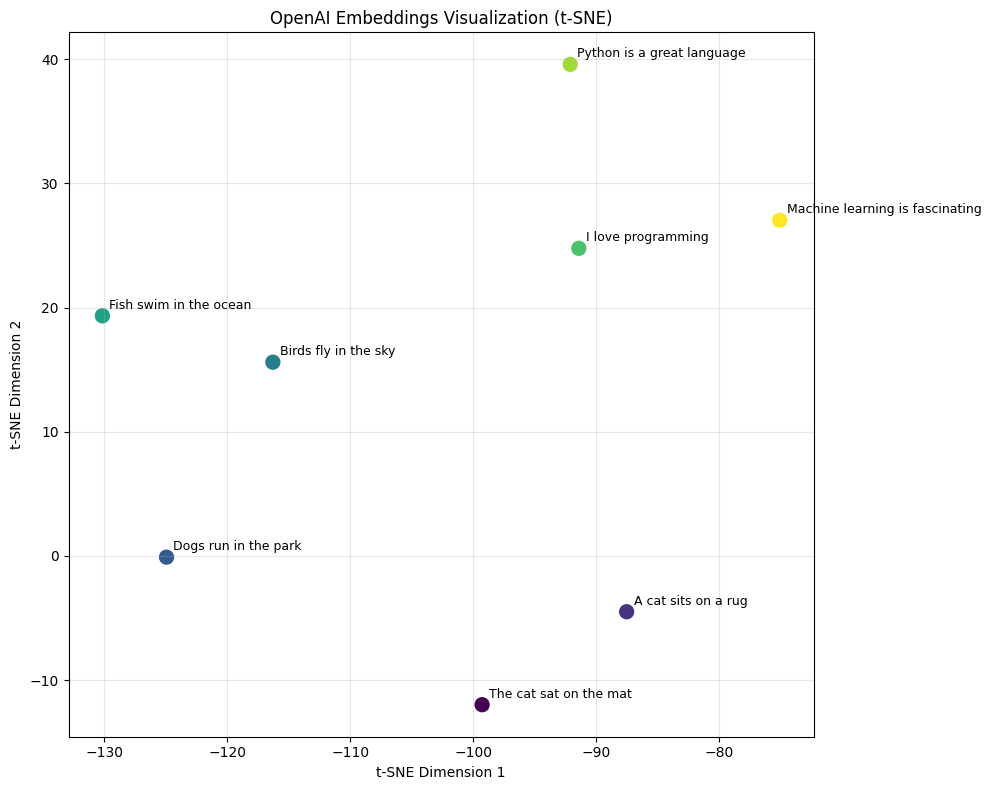

In [19]:
# Creating visualization by reducing 1536-dimensional vectors to  2-Dimensions using TNSE
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize_embeddings(vectors, labels, title="Embedding Visualization"):
    """
    Visualize high-dimensional vectors in 2D using t-SNE
    
    Args:
        vectors: List of embedding vectors
        labels: List of text labels for each vector
        title: Title for the plot
    """
    # Convert to numpy array
    vectors_array = np.array(vectors)
    # Apply t-SNE to reduce dimensions to 2D
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(vectors)-1))
    vectors_2d = tsne.fit_transform(vectors_array)
    # Create the plot
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], 
                         c=range(len(vectors)), cmap='viridis', s=100)
    # Add labels for each point
    for i, label in enumerate(labels):
        plt.annotate(label, (vectors_2d[i, 0], vectors_2d[i, 1]), 
                    xytext=(5, 5), textcoords='offset points', 
                    fontsize=9, ha='left')
    plt.title(title)
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


visualize_embeddings(all_vectors, texts, "OpenAI Embeddings Visualization (t-SNE)")

**In the above visualization observe following:**
- Similar texts should appear closer together
- Animal-related texts should cluster together
- Programming-related texts should cluster together
- Each point represents a 1536-dimensional vector reduced to 2D

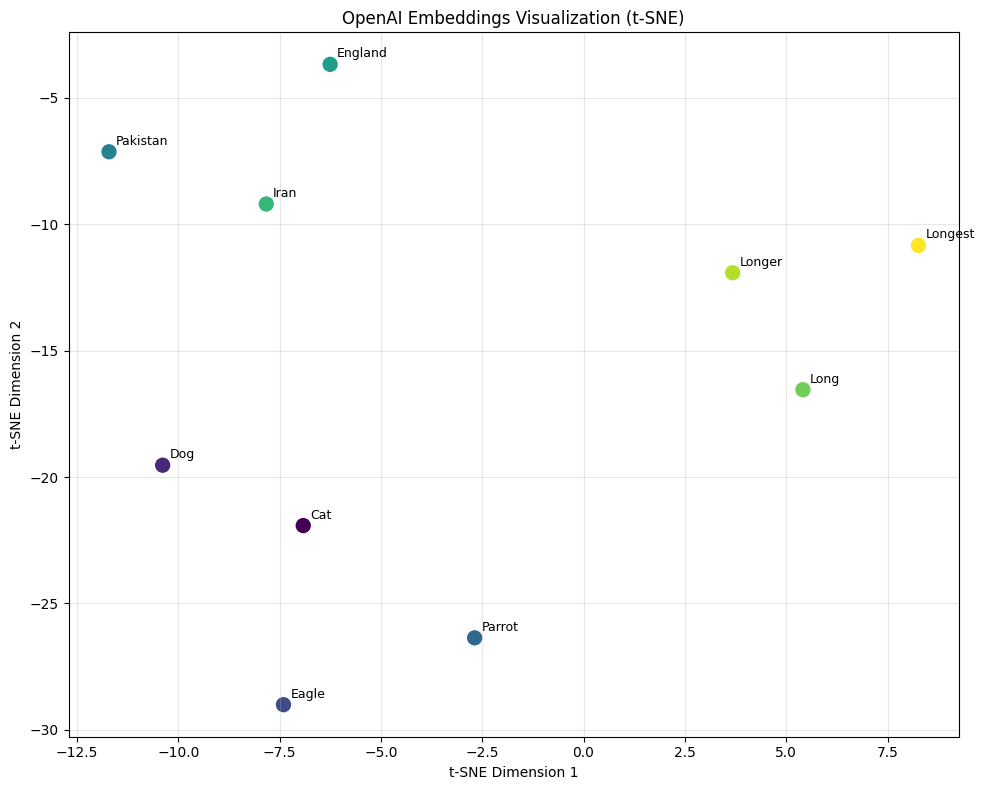

In [20]:
# Generate embeddings for all texts
texts = [
    "Cat",
    "Dog", 
    "Eagle",
    "Parrot",
    "Pakistan",
    "England",
    "Iran",
    "Long",
    "Longer",
    "Longest",
]

all_vectors = []
for text in texts:
    response = client.embeddings.create(
        input=text,
        model="text-embedding-3-small"
    )
    all_vectors.append(response.data[0].embedding)

visualize_embeddings(all_vectors, texts, "OpenAI Embeddings Visualization (t-SNE)")